In [1]:
## Reference
# https://www.coursera.org/learn/introduction-computer-vision-watson-opencv

In [2]:
import os,sys
os.chdir('/Users/levgolod/Projects/car_classifier/')

In [3]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.metrics import classification_report

import pandas as pd
# import tensorflow.compat.v1 as tf

2025-03-03 09:34:19.401839: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
from common_params import parent_directory_images, parent_directory_url_csvs
import importlib
import sys,os
import pandas as pd
from timethis import timethis



In [5]:
from _02_preprocess_data.preprocess_data_fns import *

/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:

# module_path='../02_preprocess_data/preprocess_data_fns.py'
# spec = importlib.util.spec_from_file_location("preprocess_data_fns", module_path)
# preprocess_data_fns = importlib.util.module_from_spec(spec)
# sys.modules["preprocess_data_fns"] = preprocess_data_fns
# spec.loader.exec_module(preprocess_data_fns)
# preprocess_data_fns.process_image_files

In [7]:
IMAGE_SIZE = 256 # increase later
SAMPLE_SIZE = 10000 # increase later
label_dict = {v:k for k,v in body_style_dict.items()}
print(label_dict)
class_names = list(label_dict.values())
class_names

{0: 'sedan', 1: 'sportscar', 2: 'suv', 3: 'truck', 4: 'van', 5: 'wagon'}


['sedan', 'sportscar', 'suv', 'truck', 'van', 'wagon']

### Ingest image data from disk

In [8]:
output_filename_train_val_holdout = f'{parent_directory_url_csvs}df_train_val_hold.csv'
df=pd.read_csv(output_filename_train_val_holdout).sample(frac=1)
print(df.shape)
df.partition.value_counts(dropna=False,normalize=True)

(8775, 9)


partition
train    0.715442
hold     0.154758
val      0.129801
Name: proportion, dtype: float64

torch.Size([256, 256])
d6b63c1cb72b4ec79d205eb94061b06d.jpg; true label suv


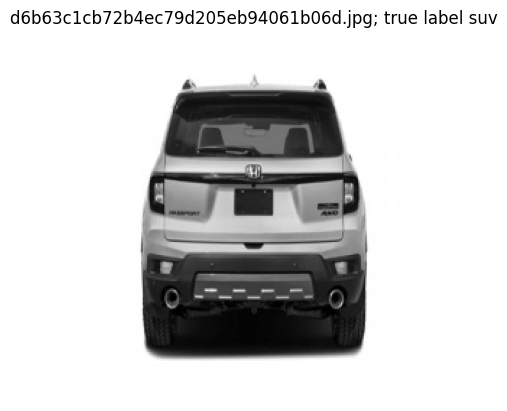

In [9]:
data_sample = df.head()[['filepath_to_use','body_style_index']].values
processed_images_sample = process_image_files(data_sample[:10], image_size=IMAGE_SIZE)

i=2
filename = os.path.basename(data_sample[i][0])
image_array = processed_images_sample[i][0] #.squeeze()
print(image_array.shape)
label = label_dict.get( processed_images_sample[i][1])
plt.imshow(image_array, cmap='gray')
plt.axis("off")
message=f"{filename}; true label {label}"
print(message)
plt.title(message)
plt.show()

In [10]:
train_dataset = process_image_files(
    df.loc[df['partition']=='train', ['filepath_to_use','body_style_index']].head(SAMPLE_SIZE).values,
    image_size=IMAGE_SIZE,
)

test_dataset = process_image_files(
    df.loc[df['partition']=='val', ['filepath_to_use','body_style_index']].head(SAMPLE_SIZE).values,
    image_size=IMAGE_SIZE,
)

holdout_dataset = process_image_files(
    df.loc[df['partition']=='hold', ['filepath_to_use','body_style_index']].head(SAMPLE_SIZE).values,
    image_size=IMAGE_SIZE,
)

print(len(train_dataset),len(test_dataset),len(holdout_dataset))

6278 1139 1358


In [11]:
train_images, train_labels = \
    [x[0] for x in train_dataset], [x[1] for x in train_dataset]

test_images, test_labels = \
    [x[0] for x in test_dataset], [x[1] for x in test_dataset]

holdout_images, holdout_labels = \
    [x[0] for x in holdout_dataset], [x[1] for x in holdout_dataset]

In [12]:
# make sure every image same size
sorted(set([str(x.shape) for x in train_images]))

['torch.Size([256, 256])']

In [13]:
## coerce to array
train_images = np.array([np.array(x) for x in train_images])
test_images = np.array([np.array(x) for x in test_images])
holdout_images = np.array([np.array(x) for x in holdout_images])

In [14]:
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
holdout_labels = np.array(holdout_labels)

In [15]:
train_images.shape

(6278, 256, 256)

In [16]:
train_images = train_images/255.0
test_images = test_images/255.0
holdout_images = holdout_images/255.0

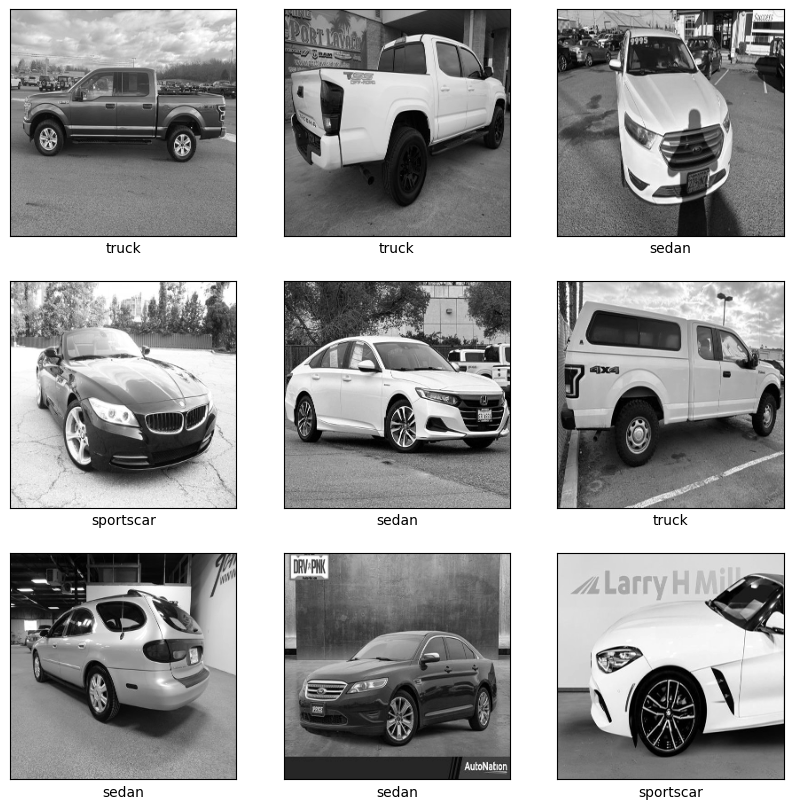

In [17]:
N=3
plt.figure(figsize=(10,10))
for i in range(N**2):
    plt.subplot(N,N,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(train_images[i]), cmap='gray')
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i]])

plt.show()

In [18]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [21]:
plt.show()
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(len(class_names))) #, activation='softmax'))

In [22]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# metrics=[
#         tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
#         tf.keras.metrics.Precision(name="precision"),
#         tf.keras.metrics.Recall(name="recall")
#     ]
# model.compile(optimizer='adam',
#               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#               metrics=metrics
#               )


history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))

Epoch 1/5
197/197 [==============================] - 151s 764ms/step - loss: 1.3850 - accuracy: 0.4642 - val_loss: 1.3085 - val_accuracy: 0.4653
Epoch 2/5
197/197 [==============================] - 147s 746ms/step - loss: 1.1558 - accuracy: 0.5658 - val_loss: 1.2534 - val_accuracy: 0.5593
Epoch 3/5
197/197 [==============================] - 152s 771ms/step - loss: 0.7954 - accuracy: 0.6989 - val_loss: 1.4817 - val_accuracy: 0.5663
Epoch 4/5
197/197 [==============================] - 147s 747ms/step - loss: 0.3901 - accuracy: 0.8594 - val_loss: 2.0988 - val_accuracy: 0.5540
Epoch 5/5
197/197 [==============================] - 146s 741ms/step - loss: 0.1444 - accuracy: 0.9501 - val_loss: 3.0682 - val_accuracy: 0.5470


In [34]:

y_pred = np.argmax(model.predict(test_images), axis=1)
# y_true = np.argmax(y_val, axis=1)
_report = classification_report(test_labels, y_pred, target_names=class_names)
print(_report)

36/36 [==============================] - 5s 138ms/step
              precision    recall  f1-score   support

       sedan       0.60      0.75      0.67       499
   sportscar       0.17      0.02      0.04        42
         suv       0.40      0.25      0.31       210
       truck       0.53      0.59      0.56       328
         van       0.20      0.05      0.08        39
       wagon       0.00      0.00      0.00        21

    accuracy                           0.55      1139
   macro avg       0.32      0.28      0.28      1139
weighted avg       0.50      0.55      0.51      1139



36/36 - 5s - loss: 3.0682 - accuracy: 0.5470 - 5s/epoch - 138ms/step


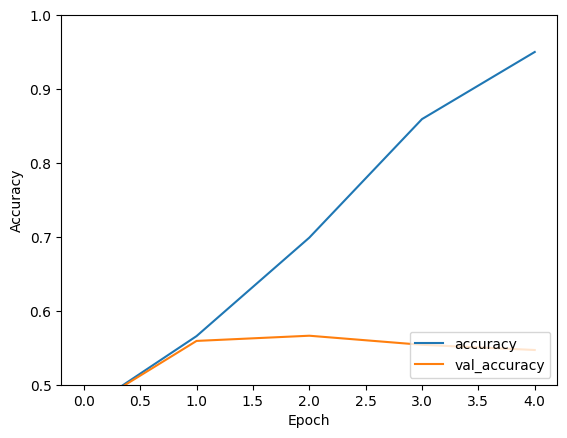

In [35]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [ ]:
# I have this trash overfitting result ughhh

In [31]:
pd.Series(test_labels).map(label_dict).value_counts()


sedan        499
truck        328
suv          210
sportscar     42
van           39
wagon         21
Name: count, dtype: int64

In [29]:
label_dict

{0: 'sedan', 1: 'sportscar', 2: 'suv', 3: 'truck', 4: 'van', 5: 'wagon'}